In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

from sequence_parser import Sequence, Variable, Variables
from sequence_parser.iq_port import Port
from sequence_parser.instruction import *

In [4]:
import sklearn
from sklearn.decomposition import PCA

In [5]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

## active reset
ef freq

In [60]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [61]:
header = "D:/K_sunada/result/CDY163/"
ef_freq = "/2024-07-24/2024-07-24T165946_b16b41aa-72_active_reset_ef_freq"
dd = datadict_from_hdf5(header + ef_freq +"/data")

S11 = dd['s11']['values']
freq = dd['ef_freq']['values']
S11_PCA = PCA_transform(S11.real, S11.imag)[0]

plt.plot(freq, S11_PCA)

In [63]:
par_ini = {'amp': 35,'const':0,'center':7.32,'k':0.008}
par_min = {'amp': 0,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf,'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True,'center':True,'k':True}

model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
result = model.fit(data = -S11_PCA, params = params, freq = freq)
result

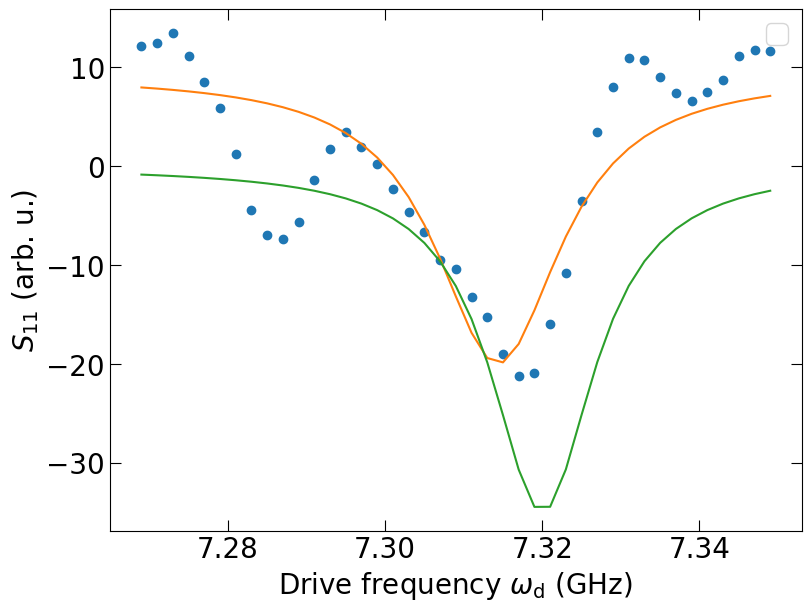

In [65]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

ef amplitude

In [66]:
ef_amp =  "/2024-07-24/2024-07-24T170953_1b3d116a-73_active_reset_ef_amp"
dd = datadict_from_hdf5(header + ef_amp +"/data")

S11 = dd['s11']['values'][0:60]
freq = dd['ef_amplitude']['values'][0:60]
S11_PCA = PCA_transform(S11.real, S11.imag)[0]

plt.plot(freq, S11_PCA)

In [67]:
def cos(x, amp, freq, phi, const):
    return amp * np.cos(2*np.pi*x*freq+phi) + const

In [69]:
par_ini= {'amp': 7,'freq':3.2,'phi':np.pi,'const':0}
par_min= {'amp': 0,'freq':0,'phi':-2*np.pi,'const':-np.inf}
par_max= {'amp': np.inf,'freq':np.inf,'phi':2*np.pi,'const':np.inf}
par_vary= {'amp': True,'freq': True,'phi': True,'const': True}

model = lmfit.Model(cos)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
result = model.fit(data = -S11_PCA, params = params, x = freq)
result

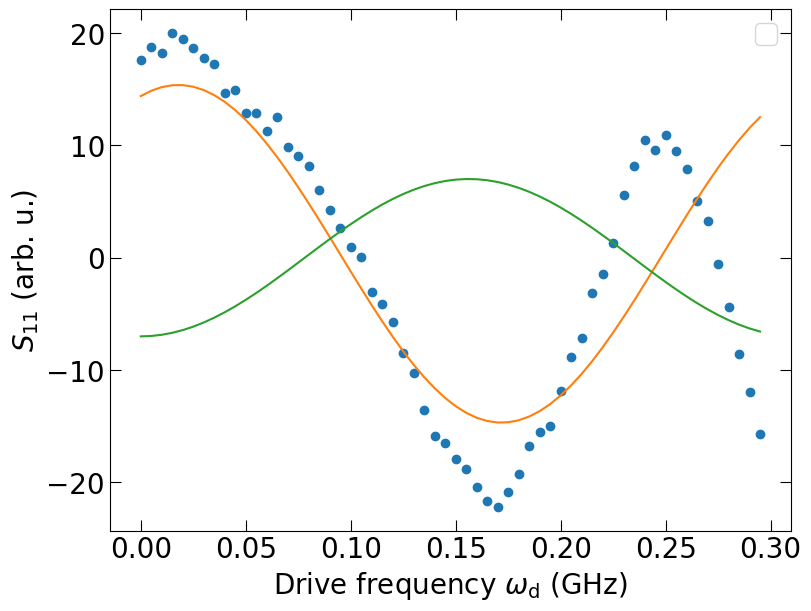

In [71]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

In [72]:
1/2/3.24804768

0.15393862691079707

## FFT

In [14]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [15]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 7/29 photon shape & photon number

In [7]:
header = "D:/K_sunada/result/CDY163/"
atten = -107.3 #dBm

In [8]:
from scipy.constants import *

In [9]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

def dbm_watt(dBm):
    return (10**(dBm/10))*1e-3

In [74]:
def photon_number(pulse, freq, atten, sample_rate):
    #pulse: [x, y, env], atten: dBm, samplerate: s, P_vna: W (AWG amp=1.0)
    x = pulse[0]
    y = pulse[2] #env

    atten_W = dbm_watt(atten)
    ene = 0
    for t in range(int(len(x)/2)):
        ene = ene + (y[2*t]**2)*sample_rate

    return ene * atten_W / (2*np.pi*hbar*freq)


## Photon shape

In [71]:
readout_lo_freq = 10.5e9
target_freq = 10.3875e9
ph_if = readout_lo_freq - target_freq
duration = 1000
const = 2.5e-3 * 2 * np.pi
sample_rate = 2e-9

0.03875211799080888

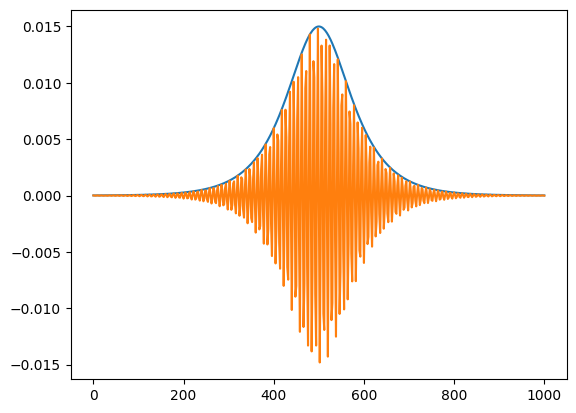

In [79]:
## sech
amp = 0.015
x = np.arange(0, 1001, 2)
y_env = 1/np.cosh(const * (x - duration/2)) * amp
y = 1/np.cosh(const * (x - duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) * amp
plt.plot(x, y_env)
plt.plot(x, y)

pulse = [x, y, y_env]
photon_number(pulse, rf_freq, atten, sample_rate)

0.035880679668491296

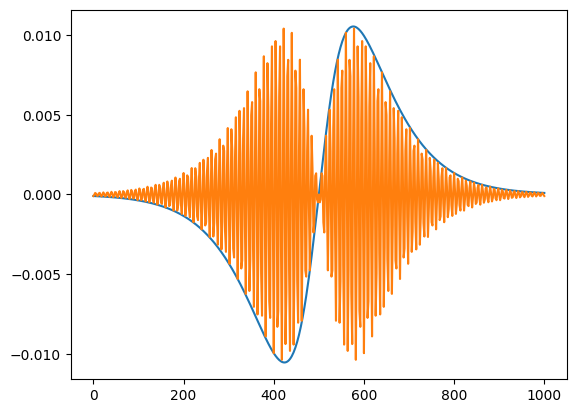

In [80]:
## anti_sech
amp = 0.00025
y_env = (x - fogi_duration/2)/np.cosh(const * (x - fogi_duration/2)) * amp
y = (x - fogi_duration/2)/np.cosh(const * (x - fogi_duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) * amp
plt.plot(x, y_env)
plt.plot(x, y)


pulse = [x, y, y_env]
photon_number(pulse, rf_freq, atten, sample_rate)